<h3/>
<h1 align="center">Universidad de Buenos Aires (FIUBA)</h1>
<h2 align="center">Especialización en Inteligencia Artificial - CEIA - FIUBA</h2>
<h2 align="center">Aprendizaje de Máquina I</h2>
<h3 align="center">Predicción de la recaudación de una película</h3>

<p align="left">
Integrantes:
  <ul>
    <li> Luis Jose Paredes Ramirez </li>
    <li> Hernando Scheidl </li>
    <li> Nicolás Lastra </li>
  <ul/>
</p>

---

# Planteo del problema y Fuente de datos

### Fuente de los datos

[Full TMDB Movies Dataset 2024 (1M Movies)](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies) es un dataset publicado por [asaniczka](https://www.kaggle.com/asaniczka) en Kaggle.

Este dataset contiene informacion sobre peliculas extraidas a partir de la API pública de [The Movie Database (TMDB)](https://developer.themoviedb.org/docs/getting-started).


### Contexto del negocio

La mayoria de las peliculas producidas por la industria del cine no tienen exito financiero. Las grandes productoras suelen apostarle fuerte a los **blockbusters** con la esperanza de que estos recauden suficiente dinero para compensar las demas peliculas.

Coloquialmente se sigue una regla de oro informal:

> Una película financieramente exitosa recauda entre dos y tres veces su presupuesto `revenue = 2 * budget`

### Planteo del Problema

En el siguiente trabajo practico se desarrollan distintos modelos de aprendizaje automatico con el objetivo de estimar la **recaudación mundial en dólares (`revenue`)** de una película a partir de sus características.

Se plantea un problema de **regresión** con una variable objetivo (`revenue`) continua, positiva y extremadamente asimétrica por naturaleza.

De entrada utilizaremos la regla de oro informal como baseline y se comparará contra los distintos modelos entrenados.

---
## 1. Descarga del dataset

Descargamos el archivo usando el SDK de [`kagglehub`](https://pypi.org/project/kagglehub/).

Recordar que `file_path` apunta al nombre del archivo que se descarga

In [ ]:
!pip install -q kagglehub optuna xgboost sklearn

In [59]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set()

# Paleta de colores usada en el Notebook
AZUL, MAGENTA, VERDE, NARANJA, CELESTE, GRIS = (
    "#007aff", "#ff48fd", "#44c57f", "#ffa600", "#8ecae6", "#555555",
)

RANDOM_STATE = 42

# Set the path to the file you'd like to load
file_path = "TMDB_movie_dataset_v11.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "asaniczka/tmdb-movies-dataset-2023-930k-movies",
  file_path
)

---
## 2. Carga y primer vistazo

El dataset tiene alrededor de un 1477463 filas y 24 columnas

In [60]:
print(f"Tenemos {df.shape[0]} y {df.shape[1]} columnas en el dataset \n")
print(f"Columnas: {df.columns}\n")
display(df.head(3))

Tenemos 1477463 y 24 columnas en el dataset 

Columnas: Index(['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date',
       'revenue', 'runtime', 'adult', 'backdrop_path', 'budget', 'homepage',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'tagline', 'genres',
       'production_companies', 'production_countries', 'spoken_languages',
       'keywords'],
      dtype='str')



,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,original_title,overview,popularity,poster_path,tagline,genres,production_companies,production_countries,spoken_languages,keywords
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,Inception,"Cobb, a skilled thief who commits corporate es...",83.952,/oYuLEt3zVCKq57qu2F8dT7NIa6f.jpg,Your mind is the scene of the crime.,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,Interstellar,The adventures of a group of explorers who mak...,140.241,/gEU2QniE6E77NI6lCU6MxlNBvIx.jpg,Mankind was born on Earth. It was never meant ...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,The Dark Knight,Batman raises the stakes in his war on crime. ...,130.643,/qJ2tW6WMUDux911r6m7haRef0WH.jpg,Welcome to a world without rules.,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f..."


---
## 3. Exploratory Data Analysis (EDA) inicial

Vemos en el [sample del dataset](https://www.kaggle.com/datasets/asaniczka/tmdb-movies-dataset-2023-930k-movies) (pestaña `Column`) la descripcion de cada columna

- `id`: Unique identifier for each movie. (type: int)
- `title`: Title of the movie. (type: str)
- `vote_average`: Average vote or rating given by viewers. (type: float)
- `vote_count`: Total count of votes received for the movie. (type: int)
- `status`: The status of the movie (type: e.g., Released, Rumored, Post Production, etc.). (type: str)
- `release_date`: Date when the movie was released. (type: str)
- `revenue`: Total revenue generated by the movie. (type: int)
- `runtime`: Duration of the movie in minutes. (type: int)
- `adult`: Indicates if the movie is suitable only for adult audiences. (type: bool)
- `backdrop_path`: URL of the backdrop image for the movie. (type: str)
- `budget`: Budget allocated for the movie. (type: int)
- `homepage`: Official homepage URL of the movie. (type: str)
- `imdb_id`: IMDb ID of the movie. (type: str)
- `original_language`: Original language in which the movie was produced. (type: str)
- `original_title`: Original title of the movie. (type: str)
- `overview`: Brief description or summary of the movie. (type: str)
- `popularity`: Popularity score of the movie. (type: float)
- `poster_path`: URL of the movie poster image. (type: str)
- `tagline`: Catchphrase or memorable line associated with the movie. (type: str)
- `genres`: List of genres the movie belongs to. (type: str)
- `production_companies`: List of production companies involved in the movie. (type: str)
- `production_countries`: List of countries involved in the movie production. (type: str)
- `spoken_languages`: List of languages spoken in the movie. (type: str)
- `keywords`: Keywords associated with the movie. Do `.split(", ")` to convert to a list. (type: str)

Como nuestro objetivo es un **problema de regresion** y nuestra variable **target** es `revenue` podemos ir descartando por conocimiento del dominio ciertas columnas que no vamos a utilizar (por ejemplo `overview`, `keywords`, `spoken_languages`, `tagline`, etc).

In [61]:
CANDIDATAS = [
    "id", "title", "status", "release_date",   # identificación y filtrado
    "revenue",                                 # TARGET
    "budget", "runtime", "popularity",         # numéricas principales
    "vote_average", "vote_count",              # recepción del público
    "original_language",                       # categórica
    "genres", "production_companies",          # listas separadas por coma
]

print(f"Columnas descartadas {set(df.columns) - set(CANDIDATAS)}")

df = df[CANDIDATAS].copy()
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")

print(f"Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")
df.head()

Columnas descartadas {'backdrop_path', 'tagline', 'homepage', 'production_countries', 'poster_path', 'spoken_languages', 'adult', 'imdb_id', 'keywords', 'original_title', 'overview'}
Dimensiones: 1,477,463 filas × 13 columnas
Memoria: 556 MB


,id,title,status,release_date,revenue,budget,runtime,popularity,vote_average,vote_count,original_language,genres,production_companies
0,27205,Inception,Released,2010-07-15,825532764,160000000,148,83.952,8.364,34495,en,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict..."
1,157336,Interstellar,Released,2014-11-05,701729206,165000000,169,140.241,8.417,32571,en,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc..."
2,155,The Dark Knight,Released,2008-07-16,1004558444,185000000,152,130.643,8.512,30619,en,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel..."
3,19995,Avatar,Released,2009-12-15,2923706026,237000000,162,79.932,7.573,29815,en,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ..."
4,24428,The Avengers,Released,2012-04-25,1518815515,220000000,143,98.082,7.710,29166,en,"Science Fiction, Action, Adventure",Marvel Studios


Vemos que existen distintos estados de produccion de una pelicula

In [62]:
df["status"].value_counts(dropna=False).head()

status
Released           1421369
In Production        25576
Post Production      16752
Planned              12493
Rumored                894
Name: count, dtype: int64

Evaluamos la calidad de los datos determinando la cantidad de datos nulos y datos unicos para las columnas filtradas

In [58]:
resumen = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "% nulos": (df.isna().mean() * 100).round(1),
    "únicos": df.nunique(),
})
resumen.sort_values("% nulos", ascending=False)

,tipo,nulos,% nulos,únicos
production_companies,str,855314,57.9,242493
genres,str,659438,44.6,15431
release_date,datetime64[us],343760,23.3,43863
id,int64,0,0.0,1476131
title,str,19,0.0,1252165
status,str,0,0.0,6
revenue,int64,0,0.0,14712
budget,int64,0,0.0,6772
runtime,int64,0,0.0,832
popularity,float64,0,0.0,20225


Vemos que las dos variables mas importanets para nuestro problema, **`revenue` & `budget`**, figuran sin ningún nulo.

Sin embargo; esto es engañoso ya que en TMDB el dato financiero faltante se codifica como **cero**, no como `NaN`. Contar nulos no detecta el problema de calidad del dataset. Lo buscamos explícitamente en la próxima sección.

### 3.1 El problema de los ceros

TMDB es una base colaborativa: cualquiera puede cargar una película, pero muy pocos se toman el
trabajo de completar los datos financieros. Veamos qué proporción del dataset tiene información
económica utilizable.

In [7]:
print(f"Total de películas: {len(df):,}")
print(f"Con revenue > 0:                 {(df['revenue'] > 0).sum():>9,}"
      f"  ({(df['revenue'] > 0).mean():.2%})")
print(f"Con budget > 0:                  {(df['budget'] > 0).sum():>9,}"
      f"  ({(df['budget'] > 0).mean():.2%})")
ambos = (df["revenue"] > 0) & (df["budget"] > 0)
print(f"Con ambos > 0:                   {ambos.sum():>9,}  ({ambos.mean():.2%})")

Total de películas: 1,477,463
Con revenue > 0:                    25,132  (1.70%)
Con budget > 0:                     86,502  (5.85%)
Con ambos > 0:                      18,118  (1.23%)


El dataset está dominado por registros con recaudacion nula `revenue = 0`. Esto no necesariamente significa "no recaudó nada" sino que tambien puede ser "nadie cargó el dato" o "el dato no es publico".

Dado que no podemos distinguien entre estos escenarios, debemos filtrar las filas con `revenue = 0`, aunque reduzca significativamente el tamano del dataset.

### 3.2 Distribución del target

Miremos cómo se distribuye `revenue` entre las películas que sí tienen el dato cargado.

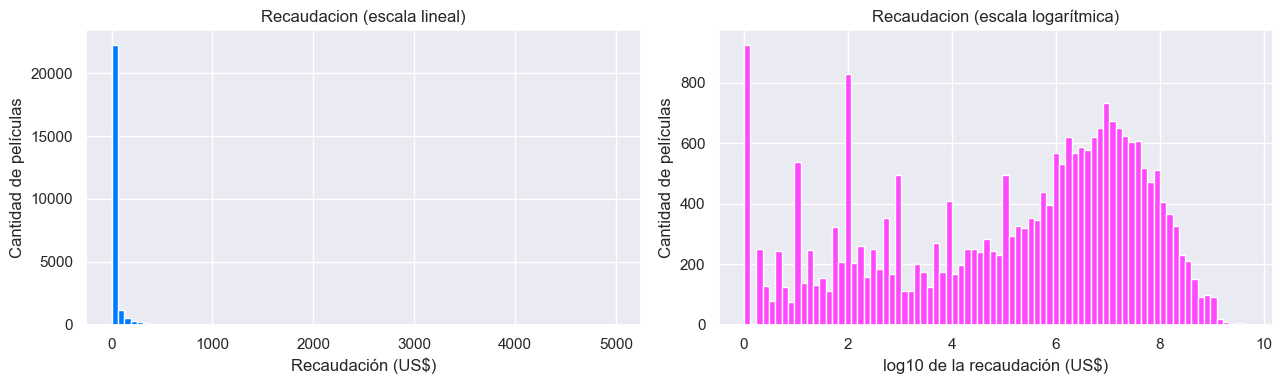

count    2.513200e+04
mean     3.573874e+07
std      1.457156e+08
min      1.000000e+00
5%       3.000000e+00
25%      1.000000e+03
50%      6.468300e+05
75%      1.263054e+07
95%      1.736042e+08
99%      6.693941e+08
max      5.000000e+09
Name: revenue, dtype: float64
Maxima recaudacion 4999999999


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

revenue_distribution = df.loc[df["revenue"] > 0, "revenue"]

axes[0].hist(revenue_distribution / 1e6, bins=80, color=AZUL, edgecolor="white")
axes[0].set_xlabel("Recaudación (US$)")
axes[0].set_ylabel("Cantidad de películas")
axes[0].set_title("Recaudacion (escala lineal)")

axes[1].hist(np.log10(revenue_distribution), bins=80, color=MAGENTA, edgecolor="white")
axes[1].set_xlabel("log10 de la recaudación (US$)")
axes[1].set_ylabel("Cantidad de películas")
axes[1].set_title("Recaudacion (escala logarítmica)")

plt.tight_layout()
plt.show()

print(revenue_distribution.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(0))
print(f"Maxima recaudacion {revenue_distribution.max()}")

Vemos que la recaudación tiene una distribucion con valores muy variados. En particular nos resalta la naturaleza de aquellas pocas peliculas que son exito financiero (**blockbusters**) y la inmensa mayoria de las peliculas recaudan poco o nada.

Dado que la escala lineal del histograma no nos dio mucha informacion utilizamos la escala logaritmica ($\log_{10}$) y observamos una distribucion que se asemeja a una normal.

Esto tiene dos consecuencias directas sobre el modelado:

1. **Vamos a entrenar sobre $\log(1 + \text{revenue})$**, no sobre `revenue`. Si no lo hacemos, el error cuadrático queda dominado por un puñado de *blockbusters* y el modelo ignora al resto del catálogo.
2. **Las métricas en dólares hay que leerlas con cuidado.** Un MAE de 40 millones puede ser excelente para *Avatar* y catastrófico para un documental. Por eso reportamos también el **MAE en $\log_{10}$**, que se interpreta como "en promedio le erramos por un factor de $10^{\text{MAE}}$".

---
## 4. Filtrado: del crudo al dataset de modelado

Antes de aplicar los filtros evaluamos cuantos datos vamos filtrando acumulativamente


Nos quedamos con las filas que cumplan:

- **`status == 'Released'`**: Peliculas lanzadas.
- **`revenue > 0` y `budget > 0`**: Datos financieros validos
- **`runtime > 0`**: descarta titulos sin duración cargada.
- **`vote_count > 0` & vote_count > 0**: `vote_count` & `vote_average` deben ser valores mayores que 0
- **Fecha de estreno y género no nulos**: sacalos los valores nulos

In [ ]:
filtros = [
    ("Dataset completo",              pd.Series(True, index=df.index)),
    ("status == 'Released'",          df["status"].eq("Released")),
    ("revenue > 0",                   df["revenue"] > 0),
    ("budget  > 0",                   df["budget"] > 0),
    ("runtime > 0",                   df["runtime"] > 0),
    ("vote_count > 0",                df["vote_count"] > 0),
    ("fecha not null",        df["release_date"].notna()),
    ("género not null",          df["genres"].notna()),
]

mascara = pd.Series(True, index=df.index)
traza = []
for nombre, condicion in filtros:
    mascara &= condicion.fillna(False)
    traza.append({"filtro": nombre,
                  "filas": int(mascara.sum()),
                  "% del original": mascara.mean() * 100})

embudo = pd.DataFrame(traza).set_index("filtro").round(2)
embudo

,filas,% del original
filtro,,
Dataset completo,1477463,100.00
status == 'Released',1421369,96.20
revenue > 0,24753,1.68
budget > 0,17762,1.20
runtime > 0,14860,1.01
vote_count > 0,10770,0.73
fecha not null,10597,0.72
género not null,10518,0.71


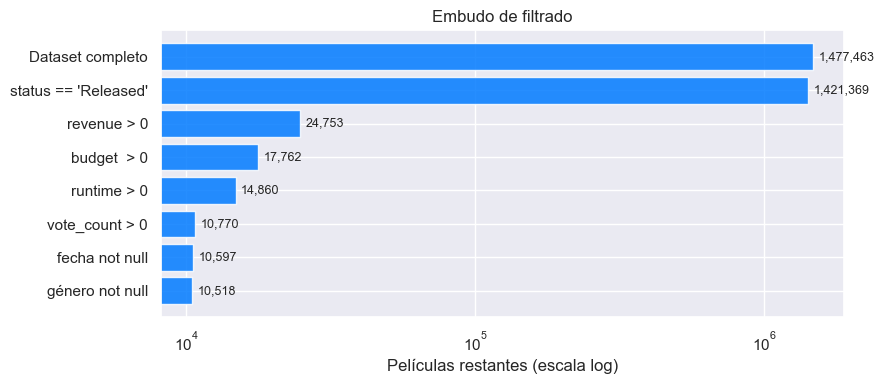

In [53]:
fig, ax = plt.subplots(figsize=(9, 4))
filas = embudo["filas"][::-1]
bars = ax.barh(embudo.index[::-1], filas, color=AZUL, alpha=0.85)
ax.bar_label(bars, labels=[f"{v:,}" for v in filas], padding=4, fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("Películas restantes (escala log)")
ax.set_title("Embudo de filtrado")
plt.tight_layout()
plt.show()

Aplicamos los filtros de forma acumulativa para ver cuánto cuesta cada uno. El criterio general es
quedarnos con **títulos estrenados que tengan cargados sus datos financieros**.

In [11]:
peliculas = df[mascara].drop_duplicates(subset="id").reset_index(drop=True)

print(f"Dataset de modelado: {len(peliculas):,} películas "
      f"({len(peliculas) / len(df):.2%} del original)")
print(f"Años cubiertos: {peliculas['release_date'].dt.year.min():.0f}"
      f" – {peliculas['release_date'].dt.year.max():.0f}")

Dataset de modelado: 10,518 películas (0.71% del original)
Años cubiertos: 1913 – 2026


Nos quedamos con un dataset chico pero **denso en información**.

Sin embargo, en el proceso hemos introducido un sesgo de selección ya que las películas que tienen datos financieros cargados en TMDB son las comercialmente relevantes. 

El modelo que entrenemos vale para ese universo y no para el catálogo completo. Lo retomamos en las conclusiones.

---
## 5. EDA sobre el dataset filtrado

### 5.1 Presupuesto contra recaudación

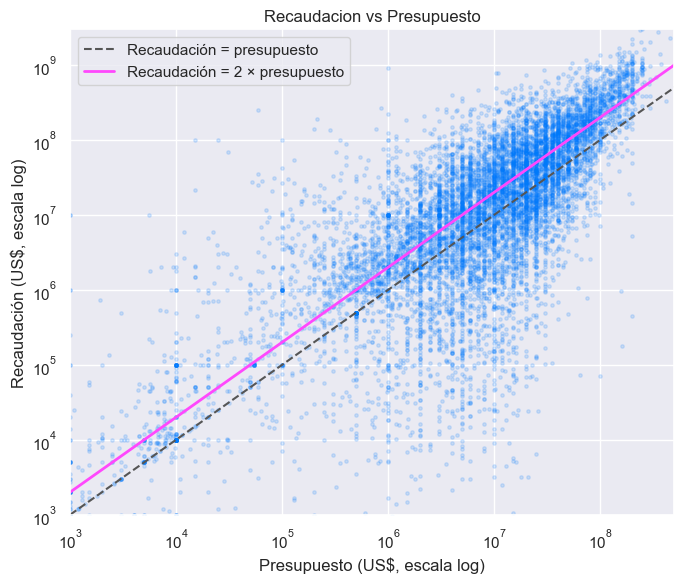

Media de revenue / budget: 1619.01
Mediana de revenue / budget: 1.75
Películas que no recuperan el presupuesto: 32.5%


In [65]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(peliculas["budget"], peliculas["revenue"], s=6, alpha=0.15, color=AZUL)
ax.set_xscale("log")
ax.set_yscale("log")

lim = [1e3, 3e9]
ax.plot(lim, lim, color=GRIS, ls="--", lw=1.5, label="Recaudación = presupuesto")
ax.plot(lim, [2 * x for x in lim], color=MAGENTA, lw=2,
        label="Recaudación = 2 × presupuesto")

ax.set_xlim(1e3, 5e8)
ax.set_ylim(1e3, 3e9)
ax.set_xlabel("Presupuesto (US$, escala log)")
ax.set_ylabel("Recaudación (US$, escala log)")
ax.set_title("Recaudacion vs Presupuesto")
ax.legend()
plt.tight_layout()
plt.show()

ratio = peliculas["revenue"] / peliculas["budget"]
print(f"Media de revenue / budget: {ratio.mean():.2f}")
print(f"Mediana de revenue / budget: {ratio.median():.2f}")
print(f"Películas que no recuperan el presupuesto: {(ratio < 1).mean():.1%}")

En escala log-log la nube tiene una tendencia lineal clara: **el presupuesto es por lejos el mejor
predictor individual**. Pero la dispersión vertical alrededor de la tendencia es de más de un orden
de magnitud, y eso es exactamente lo que un modelo puede intentar explicar con el resto de las
variables.

La línea magenta es nuestra futura *baseline*: la regla del múltiplo del presupuesto `revenue = 2 * budget`

Con respecto a los dos estadisticos utilizados, tenemos una media de 1.619 contra una mediana de 1.75. Esto quiere decir que en nuestros datos, la pelicula promedio recauda 1.619 veces su presupuesto, lo cual sabemos que no es el cierto. 

Siendo que la media no es un estadistico robusto (sensible a los outliers) utilizaremos la mediana como un mejor estadistico en este caso.

Por ultimo resaltamos que el 32.5% de las peliculas no recuperan el presupuesto. Esto es consistente con el negocio

### 5.2 Correlaciones

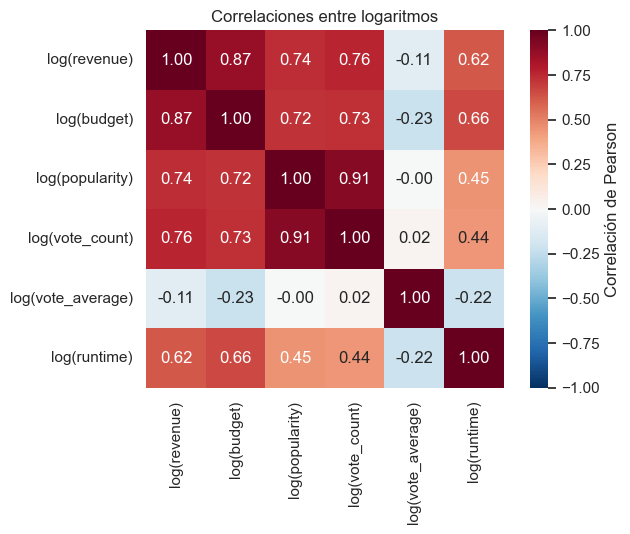

In [13]:
numericas_eda = ["revenue", "budget", "popularity", "vote_count",
                 "vote_average", "runtime"]
log_eda = np.log1p(peliculas[numericas_eda])
log_eda.columns = [f"log({c})" for c in numericas_eda]

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(log_eda.corr(), annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title("Correlaciones entre logaritmos")
plt.tight_layout()
plt.show()

Trabajamos con los logaritmos porque la correlación de Pearson sobre las variables originales estaría dominada por los valores extremos.

Llama bastante la atencion:

- `log(budget)` y `log(vote_count)` son las dos variables más correlacionadas con el target.
- `vote_average` casi no correlaciona. Es decir, que una película sea buena no implica que recaude, un resultado poco intuitivo pero muy consistente con lo que se sabe de la industria.

> `popularity`, `vote_count` y `vote_average` son variables medidas *después* del estreno. Nuestro modelo no las puede usar para decidir si financiar una película. Volvemos sobre esto al final.

### 5.3 Géneros y evolución temporal

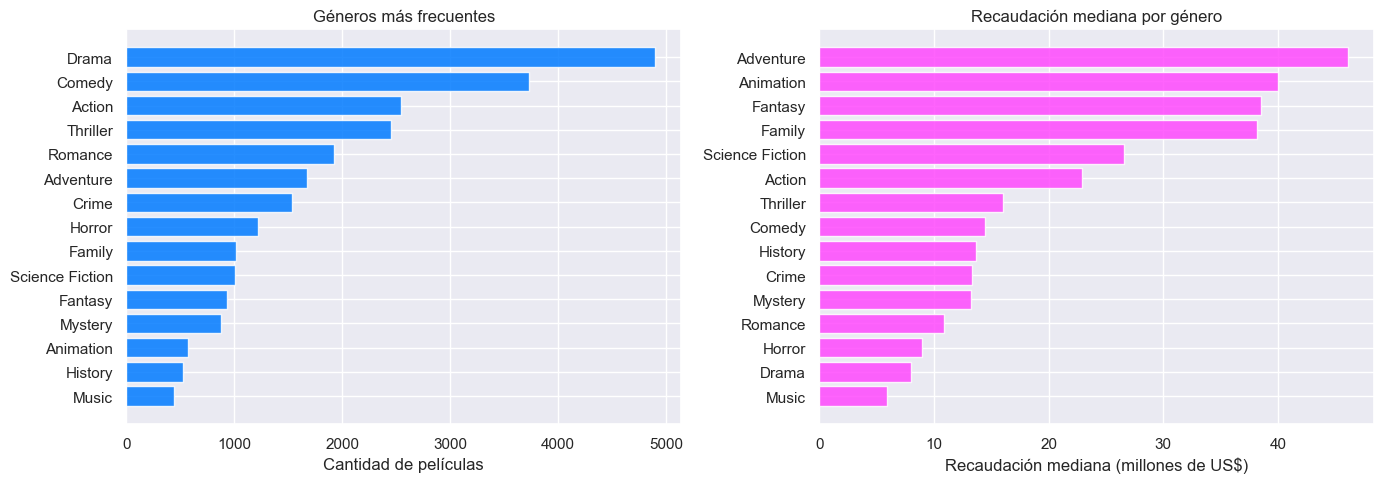

In [14]:
def parsear_lista(valor):
    """Convierte 'Drama, Crime' en ['Drama', 'Crime']."""
    if pd.isna(valor):
        return []
    return [parte.strip() for parte in str(valor).split(",") if parte.strip()]


generos_expandidos = peliculas["genres"].apply(parsear_lista).explode().dropna()
conteo_generos = generos_expandidos.value_counts()

recaudacion_por_genero = (
    peliculas.assign(genero=peliculas["genres"].apply(parsear_lista))
    .explode("genero")
    .groupby("genero")["revenue"]
    .median()
    .reindex(conteo_generos.index)
    / 1e6
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(conteo_generos.index[:15][::-1], conteo_generos.values[:15][::-1],
             color=AZUL, alpha=0.85)
axes[0].set_xlabel("Cantidad de películas")
axes[0].set_title("Géneros más frecuentes")

top15 = recaudacion_por_genero.head(15).sort_values()
axes[1].barh(top15.index, top15.values, color=MAGENTA, alpha=0.85)
axes[1].set_xlabel("Recaudación mediana (millones de US$)")
axes[1].set_title("Recaudación mediana por género")

plt.tight_layout()
plt.show()

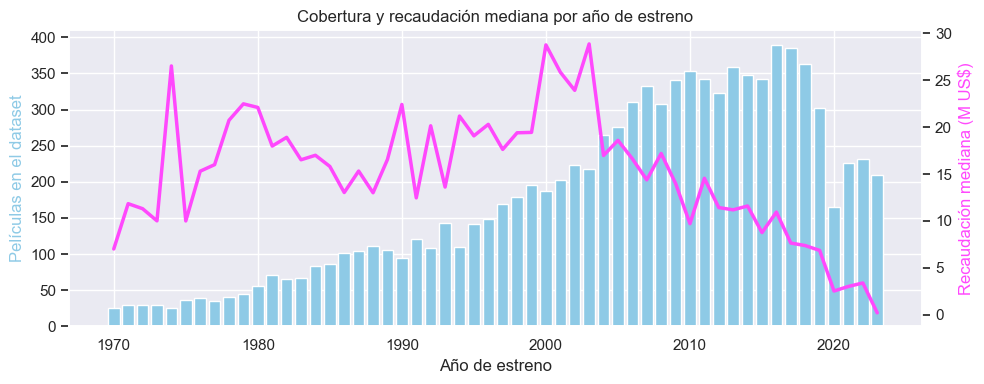

In [15]:
por_anio = (peliculas
            .assign(anio=peliculas["release_date"].dt.year)
            .query("1970 <= anio <= 2023")
            .groupby("anio")
            .agg(peliculas=("revenue", "size"),
                 mediana=("revenue", "median")))

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(por_anio.index, por_anio["peliculas"], color=CELESTE, label="Películas")
ax.set_xlabel("Año de estreno")
ax.set_ylabel("Películas en el dataset", color=CELESTE)

ax2 = ax.twinx()
ax2.plot(por_anio.index, por_anio["mediana"] / 1e6, color=MAGENTA, lw=2.5,
         label="Recaudación mediana")
ax2.set_ylabel("Recaudación mediana (M US$)", color=MAGENTA)
ax2.grid(False)

ax.set_title("Cobertura y recaudación mediana por año de estreno")
plt.tight_layout()
plt.show()

La cobertura del dataset crece fuerte hacia el presente y la recaudación mediana cae. A medida
que se agregan estrenos recientes entran muchas producciones chicas que antes no se registraban. El
año de estreno, entonces, no es solo una variable temporal: también captura *cómo se armó el
dataset*. Lo incluimos como *feature* teniéndolo presente.

---
## 6. Ingeniería de *features*

Construimos la matriz de diseño con las variables elegidas y el tratamiento que necesita cada grupo:

| Grupo | Variables | Tratamiento |
|---|---|---|
| **Sesgadas** | `budget`, `popularity`, `vote_count`, `n_companias` | $\log(1+x)$ y luego estandarización |
| **Numéricas** | `runtime`, `vote_average`, `anio` | Estandarización |
| **Categórica** | `idioma` (8 más frecuentes + `otro`) | *One-hot* |
| **Binarias** | 12 indicadores de género | Se pasan tal cual (ya son 0/1) |

Tres decisiones que vale la pena explicar:

**Por qué el logaritmo en las sesgadas.** `budget`, `popularity` y `vote_count` abarcan varios
órdenes de magnitud, igual que el target. Estandarizarlas directamente dejaría casi todas las
películas amontonadas cerca de cero y unas pocas a diez desvíos de distancia; el $\log(1+x)$ las
vuelve aproximadamente simétricas y recién ahí la estandarización tiene sentido.

**Por qué los géneros no van con *one-hot*.** Son **multietiqueta**: una película puede ser
simultáneamente *Action* y *Comedy*. Un `OneHotEncoder` clásico asume categorías excluyentes, así
que usamos un **indicador binario por género** —doce columnas que pueden valer 1 al mismo tiempo—.

**Por qué se estandariza aunque haya árboles.** A Random Forest y XGBoost el escalado les da igual:
una transformación monótona no cambia dónde cortan. Pero Ridge y KNN lo necesitan sí o sí —el
primero porque la penalización castiga a los coeficientes según la escala de su variable, el segundo
porque las distancias quedarían dominadas por `budget`, que se mide en millones—. Aplicar el mismo
preprocesamiento a todos mantiene la comparación limpia y no perjudica a nadie.

In [16]:
TOP_GENEROS = conteo_generos.head(12).index.tolist()
TOP_IDIOMAS = peliculas["original_language"].value_counts().head(8).index.tolist()

print(f"Géneros: {TOP_GENEROS}")
print(f"Idiomas: {TOP_IDIOMAS}")

Géneros: ['Drama', 'Comedy', 'Action', 'Thriller', 'Romance', 'Adventure', 'Crime', 'Horror', 'Family', 'Science Fiction', 'Fantasy', 'Mystery']
Idiomas: ['en', 'hi', 'fr', 'ru', 'es', 'ja', 'ta', 'zh']


In [17]:
def construir_features(datos):
    """Arma la matriz de diseño a partir del dataframe filtrado."""
    listas_generos = datos["genres"].apply(parsear_lista)

    matriz = pd.DataFrame(index=datos.index)

    # Sesgadas (se les aplica log en el pipeline)
    matriz["budget"] = datos["budget"]
    matriz["popularity"] = datos["popularity"]
    matriz["vote_count"] = datos["vote_count"]
    matriz["n_companias"] = (datos["production_companies"]
                             .apply(parsear_lista).str.len())

    # Numéricas
    matriz["runtime"] = datos["runtime"]
    matriz["vote_average"] = datos["vote_average"]
    matriz["anio"] = datos["release_date"].dt.year

    # Categórica: los idiomas poco frecuentes se agrupan en "otro"
    matriz["idioma"] = datos["original_language"].where(
        datos["original_language"].isin(TOP_IDIOMAS), "otro")

    # Binarias: un indicador por género (multietiqueta)
    for genero in TOP_GENEROS:
        columna = "gen_" + genero.lower().replace(" ", "_")
        matriz[columna] = listas_generos.apply(lambda gs, g=genero: int(g in gs))

    return matriz


SESGADAS = ["budget", "popularity", "vote_count", "n_companias"]
NUMERICAS = ["runtime", "vote_average", "anio"]
CATEGORICAS = ["idioma"]
BINARIAS = ["gen_" + g.lower().replace(" ", "_") for g in TOP_GENEROS]

X = construir_features(peliculas)
y = peliculas["revenue"]

print(f"Matriz de features: {X.shape[0]:,} filas × {X.shape[1]} columnas")
X.head()

Matriz de features: 10,518 filas × 20 columnas


,budget,popularity,vote_count,n_companias,runtime,vote_average,anio,idioma,gen_drama,gen_comedy,gen_action,gen_thriller,gen_romance,gen_adventure,gen_crime,gen_horror,gen_family,gen_science_fiction,gen_fantasy,gen_mystery
0,160000000,83.952,34495,3,148,8.364,2010,en,0,0,1,0,0,1,0,0,0,1,0,0
1,165000000,140.241,32571,3,169,8.417,2014,en,1,0,0,0,0,1,0,0,0,1,0,0
2,185000000,130.643,30619,5,152,8.512,2008,en,1,0,1,1,0,0,1,0,0,0,0,0
3,237000000,79.932,29815,4,162,7.573,2009,en,0,0,1,0,0,1,0,0,0,1,1,0
4,220000000,98.082,29166,1,143,7.710,2012,en,0,0,1,0,0,1,0,0,0,1,0,0


### Nulos

Verificamos que no queden valores faltantes antes de entrenar. Los filtros de la sección 4 ya
descartaron implícitamente casi todos —una fila sin `runtime` no pasa el filtro `runtime >= 40`, y
una sin fecha de estreno tampoco—, así que este paso funciona como **red de seguridad**: si no
elimina ninguna fila, mejor, pero deja constancia explícita de que la matriz está completa.

Descartamos las filas incompletas en lugar de imputarlas. Con un dataset ya reducido podría parecer
caro tirar filas, pero imputar la media de `budget` en una película sin presupuesto cargado sería
inventar justo el dato que más pesa en la predicción.

In [18]:
nulos_por_columna = X.isna().sum()
print("Nulos por columna:")
print(nulos_por_columna[nulos_por_columna > 0]
      if nulos_por_columna.any() else "  (ninguno)")

# Descartamos las filas incompletas: son pocas y no queremos imputar valores
# inventados en las variables que más pesan en el modelo
completas = X.notna().all(axis=1) & y.notna()

X, y = X[completas], y[completas]
print(f"\nFilas descartadas por nulos: {(~completas).sum()}")
print(f"Dataset final: {len(X):,} películas × {X.shape[1]} features")

Nulos por columna:
  (ninguno)

Filas descartadas por nulos: 0
Dataset final: 10,518 películas × 20 features


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f"Entrenamiento: {len(X_train):,} películas")
print(f"Testeo:        {len(X_test):,} películas")
print(f"\nRecaudación mediana — train: {y_train.median() / 1e6:6.1f} M US$ | "
      f"test: {y_test.median() / 1e6:6.1f} M US$")

Entrenamiento: 8,414 películas
Testeo:        2,104 películas

Recaudación mediana — train:   11.3 M US$ | test:   11.8 M US$


---
## 7. Función de evaluación

Reproducimos la función `evaluar` que venimos usando en la materia, con tres adaptaciones para este
problema:

- Los montos se reportan en **millones de dólares** para que la tabla sea legible.
- Agregamos el **MAE en $\log_{10}$**, que mide el error en órdenes de magnitud y no queda
  secuestrado por los *blockbusters*. Un valor de $0{,}5$ significa que, en promedio, le erramos por
  un factor de $10^{0{,}5} \approx 3{,}2$.
- **Reemplazamos el MAPE por su versión mediana, el MedAPE.**

El último cambio merece explicación, porque es consecuencia directa de cómo filtramos. El MAPE
promedia errores **relativos**: cada película aporta $|y - \hat{y}| / y$. Al haber decidido conservar
todas las filas con `revenue > 0`, quedaron adentro unas pocas decenas de registros con
recaudaciones de uno o dos dólares —errores de carga, no películas reales—. Para una película con
$y = 1$ y una predicción de diez millones, ese cociente vale **diez millones**, y un solo caso así
arrastra el promedio de las casi 1.800 películas del conjunto de testeo.

El MedAPE toma la **mediana** en lugar del promedio, así que unas pocas filas patológicas no lo
mueven: sigue respondiendo "en la película típica, ¿por qué porcentaje le erramos?", que es la
pregunta que nos interesaba. Es el mismo razonamiento por el cual la mediana es preferible a la media
para describir sueldos.

> Esto ilustra algo más general que vale la pena registrar: **las decisiones de limpieza y las de
> evaluación no son independientes**. Aflojar un filtro puede dejar inservible una métrica que
> funcionaba bien, sin que nada falle ni avise. La única forma de detectarlo es mirar los números y
> desconfiar de los que se ven raros.

Todos los modelos se evalúan igual: MAE de entrenamiento (para detectar sobreajuste), MAE por
validación cruzada de 5 pliegues sobre el conjunto de entrenamiento, y el resto de las métricas
sobre el conjunto de testeo.

In [20]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:  # scikit-learn < 1.4
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))


def mae_log10(y_true, y_pred):
    """Error absoluto medio en órdenes de magnitud."""
    return mean_absolute_error(np.log10(np.clip(y_true, 1, None)),
                               np.log10(np.clip(y_pred, 1, None)))


def medape(y_true, y_pred):
    """Error porcentual MEDIANO: versión robusta del MAPE."""
    return float(np.median(np.abs(y_true - y_pred) / y_true))


def evaluar(nombre, modelo, cv=True):
    """Entrena, evalúa en test y (opcionalmente) estima el MAE por CV."""
    millon = 1e6
    mae_cv = np.nan
    if cv:
        mae_cv = -cross_val_score(modelo, X_train, y_train, cv=5,
                                  scoring="neg_mean_absolute_error",
                                  n_jobs=-1).mean()

    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "MAE train [M US$]": mean_absolute_error(
            y_train, modelo.predict(X_train)) / millon,
        "MAE CV [M US$]": mae_cv / millon,
        "MAE test [M US$]": mean_absolute_error(y_test, y_pred) / millon,
        "RMSE [M US$]": root_mean_squared_error(y_test, y_pred) / millon,
        "MedAPE": medape(y_test, y_pred),
        "MAE log10": mae_log10(y_test, y_pred),
        "R2": r2_score(y_test, y_pred),
    }

---
## 8. Baselines

Antes de traer cualquier modelo sofisticado necesitamos saber **contra qué comparar**. Nuestra
referencia es **el múltiplo del presupuesto**:

$$\widehat{\text{revenue}} = k \cdot \text{budget}$$

con $k$ estimado como la **mediana** del cociente $\text{revenue}/\text{budget}$ en el conjunto de
entrenamiento. Es la formalización de la regla de oro de la industria —"una película recauda dos o
tres veces su presupuesto"— y tiene tres virtudes como referencia:

- **Un solo parámetro**, estimado con una mediana. No hay nada que ajustar ni que pueda sobreajustar.
- **Es la hipótesis que un productor usaría de verdad**, así que superarla es un resultado con
  significado concreto, no solo estadístico.
- **Nunca predice un disparate.** Al ser proporcional al presupuesto, sus predicciones se mantienen
  en el rango razonable. Esto importa más de lo que parece: los baselines que ajustan en escala
  logarítmica y vuelven a dólares con $\exp$ producen algunas predicciones desmedidas, y el error
  cuadrático las castiga tan fuerte que terminan con $R^2$ negativo.

Lo implementamos como un estimador de scikit-learn para que pase por la misma función `evaluar` que
todo lo demás, validación cruzada incluida.

No incluimos un modelo *dummy* de referencia —uno que prediga siempre la misma constante— porque esa
información ya está en el $R^2$: la métrica está **definida** como la mejora sobre predecir la media
del target, así que un $R^2$ de $0{,}48$ se lee directamente como "explica el 48% de la varianza que
un modelo sin *features* no explicaría". Tener además la fila sería redundante.

In [21]:
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


class MultiploDelPresupuesto(RegressorMixin, BaseEstimator):
    """Regla de la industria: revenue = k · budget, con k = mediana del ratio."""

    def __init__(self, columna="budget"):
        self.columna = columna

    def fit(self, X, y):  # noqa: N803
        self.k_ = float(np.median(np.asarray(y) / X[self.columna].to_numpy()))
        return self

    def predict(self, X):  # noqa: N803
        return self.k_ * X[self.columna].to_numpy()

In [22]:
# Guardamos los estimadores en un diccionario: `evaluar` los deja entrenados
estimadores = {
    "Múltiplo del presupuesto": MultiploDelPresupuesto(),
}

baselines = [evaluar(nombre, est) for nombre, est in estimadores.items()]

pd.DataFrame(baselines).set_index("modelo").round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Múltiplo del presupuesto,42.56,42.585,42.433,123.33,0.728,0.573,0.382


In [23]:
k = estimadores["Múltiplo del presupuesto"].k_
ratios = y_train / X_train["budget"]

print(f"Múltiplo aprendido en entrenamiento: k = {k:.2f}")
print(f"Cuartiles del ratio revenue/budget:  "
      f"{ratios.quantile(0.25):.2f}  |  {ratios.quantile(0.5):.2f}  |  "
      f"{ratios.quantile(0.75):.2f}")

Múltiplo aprendido en entrenamiento: k = 1.73
Cuartiles del ratio revenue/budget:  0.66  |  1.73  |  3.89


La regla captura una porción considerable de la señal con un único parámetro, y su $R^2$ positivo
confirma que le gana con holgura a no usar ninguna información.

Dos observaciones sobre el $k$ aprendido:

- **Queda por debajo del folclórico "dos o tres veces".** No es que la regla de la industria esté
  mal, es que se refiere a los estrenos grandes: nuestro dataset incluye producciones chicas y un
  tercio de las películas **no recupera su presupuesto**. La mediana del ratio lo refleja.
- **Es una mediana, no un promedio**, y eso es deliberado. El cociente
  $\text{revenue}/\text{budget}$ tiene una cola derecha extremísima —hay películas que multiplican
  su presupuesto por mil— y el promedio quedaría dominado por ellas. Los cuartiles que imprimimos
  abajo muestran cuán asimétrica es la distribución.

Este es el número a batir. Que un modelo con veinte variables le gane a una regla de un solo
parámetro no está garantizado de antemano, y es justamente lo que hace que la comparación valga la
pena.

---
## 9. Modelos

Elegimos cuatro modelos vistos en la materia que cubren familias bien distintas:

| Modelo | Familia | Por qué lo elegimos |
|---|---|---|
| **Ridge** | Lineal regularizada | Extiende el baseline a todas las *features*. Sirve para medir cuánto aporta la no linealidad: si un modelo complejo no le gana, la relación es esencialmente lineal en logaritmos. |
| **KNN** | Basado en distancias | No asume ninguna forma funcional. Con *features* estandarizadas, predice a partir de "películas parecidas". Es el más sensible a la maldición de la dimensionalidad. |
| **Random Forest** | *Bagging* de árboles | Captura interacciones (por ejemplo *presupuesto alto* × *género acción*) sin que se las especifiquemos, y es robusto a valores atípicos. |
| **XGBoost** | *Boosting* de árboles | Suele ser el más preciso en datos tabulares. Lo incluimos como techo de referencia. |

### Preprocesamiento

Todos comparten el mismo `ColumnTransformer`. Las variables sesgadas pasan por $\log(1+x)$ antes de
estandarizarse; a los árboles no les hace falta, pero mantener un único preprocesador hace la
comparación limpia y no los perjudica (una transformación monótona no cambia los cortes).

El target se transforma con `TransformedTargetRegressor`: **todos** los modelos aprenden sobre
$\log(1+\text{revenue})$ y devuelven predicciones en dólares.

In [24]:
from sklearn.base import clone

preprocesador = ColumnTransformer([
    # log + estandarización para las variables de muchos órdenes de magnitud
    ("sesgadas", Pipeline([("log", FunctionTransformer(np.log1p)),
                           ("escala", StandardScaler())]), SESGADAS),
    # estandarización a secas para el resto de las numéricas
    ("numericas", StandardScaler(), NUMERICAS),
    # one-hot para la categórica
    ("categoricas", OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False), CATEGORICAS),
    # los indicadores de género ya son 0/1
    ("binarias", "passthrough", BINARIAS),
])


def armar(estimador):
    """Preprocesamiento + modelo, con el target en escala logarítmica."""
    return TransformedTargetRegressor(
        regressor=Pipeline([("prep", preprocesador),
                            ("modelo", clone(estimador))]),
        func=np.log1p,
        inverse_func=np.expm1,
    )

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

modelos = {
    "Ridge": Ridge(alpha=1.0),
    "KNN (k=15)": KNeighborsRegressor(n_neighbors=15, weights="distance"),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=2,
        random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost": XGBRegressor(
        n_estimators=600, learning_rate=0.05, max_depth=5,
        subsample=0.8, colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=-1),
}

estimadores.update({nombre: armar(est) for nombre, est in modelos.items()})

resultados = [evaluar(nombre, estimadores[nombre]) for nombre in modelos]

pd.DataFrame(resultados).set_index("modelo").round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Ridge,33.252,33.602,33.509,127.556,0.627,0.496,0.339
KNN (k=15),0.000,36.057,33.707,102.788,0.642,0.503,0.571
Random Forest,14.762,29.231,28.902,85.041,0.590,0.455,0.706
XGBoost,23.133,28.670,28.291,89.520,0.592,0.453,0.674


### 9.1 Comparativa completa

In [28]:
comparativa = pd.DataFrame(baselines + resultados).set_index("modelo")
comparativa.round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Múltiplo del presupuesto,42.560,42.585,42.433,123.330,0.728,0.573,0.382
Ridge,33.252,33.602,33.509,127.556,0.627,0.496,0.339
KNN (k=15),0.000,36.057,33.707,102.788,0.642,0.503,0.571
Random Forest,14.762,29.231,28.902,85.041,0.590,0.455,0.706
XGBoost,23.133,28.670,28.291,89.520,0.592,0.453,0.674


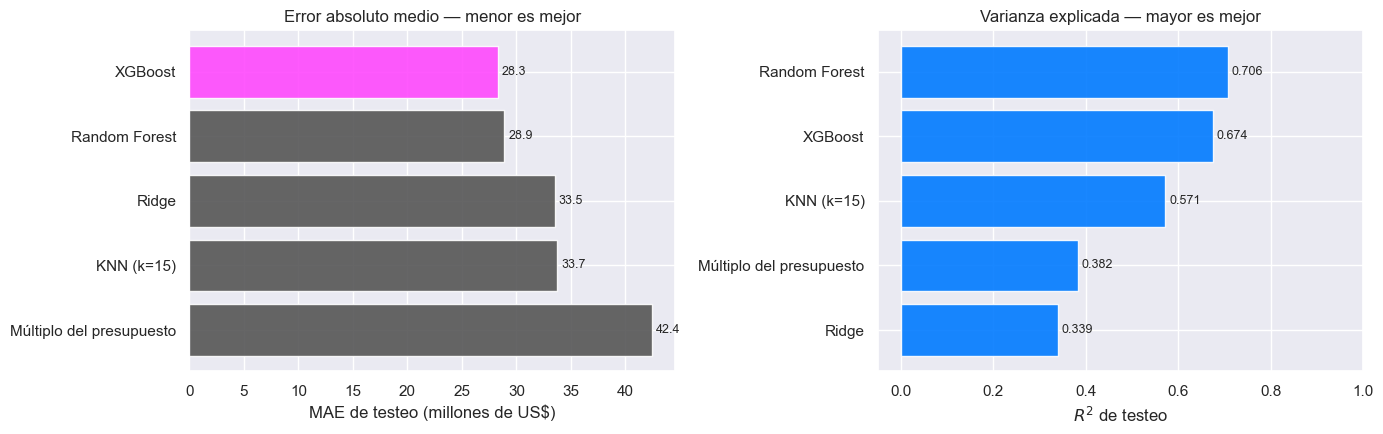

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

orden = comparativa.sort_values("MAE test [M US$]")
colores = [GRIS] * len(orden)
colores[0] = MAGENTA  # el mejor

bars = axes[0].barh(orden.index[::-1], orden["MAE test [M US$]"][::-1],
                    color=colores[::-1], alpha=0.9)
axes[0].bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
axes[0].set_xlabel("MAE de testeo (millones de US$)")
axes[0].set_title("Error absoluto medio — menor es mejor")

orden_r2 = comparativa.sort_values("R2", ascending=False)
bars = axes[1].barh(orden_r2.index[::-1], orden_r2["R2"][::-1],
                    color=AZUL, alpha=0.9)
axes[1].bar_label(bars, fmt="%.3f", padding=3, fontsize=9)
axes[1].set_xlabel("$R^2$ de testeo")
axes[1].set_title("Varianza explicada — mayor es mejor")
axes[1].set_xlim(min(0, orden_r2["R2"].min()) - 0.05, 1)

plt.tight_layout()
plt.show()

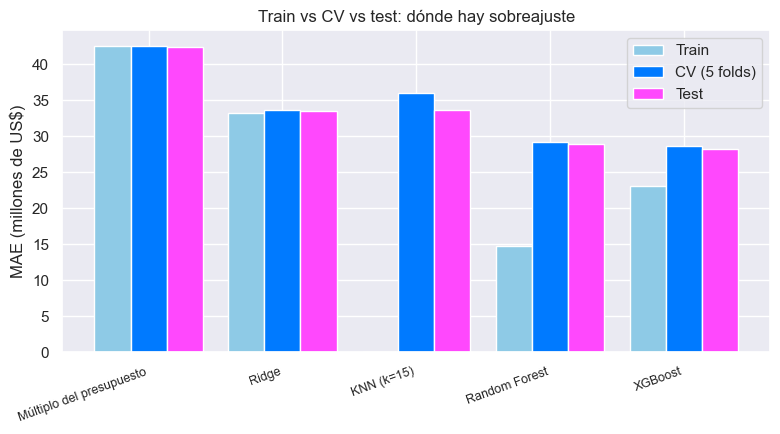

In [30]:
fig, ax = plt.subplots(figsize=(8, 4.5))

sub = comparativa.dropna(subset=["MAE CV [M US$]"])
posiciones = np.arange(len(sub))
ancho = 0.27

ax.bar(posiciones - ancho, sub["MAE train [M US$]"], ancho,
       label="Train", color=CELESTE)
ax.bar(posiciones, sub["MAE CV [M US$]"], ancho, label="CV (5 folds)", color=AZUL)
ax.bar(posiciones + ancho, sub["MAE test [M US$]"], ancho, label="Test", color=MAGENTA)

ax.set_xticks(posiciones)
ax.set_xticklabels(sub.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("MAE (millones de US$)")
ax.set_title("Train vs CV vs test: dónde hay sobreajuste")
ax.legend()
plt.tight_layout()
plt.show()

La comparación **train / CV / test** es la que más información da sobre el comportamiento de cada
modelo. El baseline tiene las tres barras casi iguales —con un solo parámetro no hay capacidad para
sobreajustar—, mientras que los modelos de árboles muestran un MAE de entrenamiento notablemente más
bajo que el de validación cruzada. Esa brecha es sobreajuste; lo importante es que **CV y test sean
consistentes entre sí**, que es lo que valida que la comparación no está contaminada.

El caso extremo es **KNN, con un MAE de entrenamiento exactamente cero**. No es un error de cálculo:
al usar `weights="distance"`, el vecino que está a distancia cero —la propia película, que está en
el conjunto de entrenamiento— recibe peso infinito y la predicción la reproduce exacta. KNN
*memoriza* el entrenamiento por construcción, así que en este modelo el MAE de entrenamiento no
informa absolutamente nada y hay que mirar sí o sí el de validación cruzada.

### 9.2 Ajuste de hiperparámetros

Hasta acá los cuatro modelos corrieron con configuraciones razonables pero elegidas a mano. Ahora
los ajustamos **a todos**, no solo al que iba ganando: comparar un modelo optimizado contra tres sin
optimizar no diría nada sobre cuál es mejor, solo sobre cuál recibió más atención.

Cada uno se ajusta con **el método que usa la notebook de la materia donde se lo presenta**:

| Modelo | Método | Notebook de referencia |
|---|---|---|
| Ridge | `GridSearchCV` sobre `alpha` | clase 3 — *Auxiliar: Regresión Lineal* |
| KNN | `GridSearchCV` sobre `n_neighbors`, `weights`, `p` | clase 2 — *Hiper-parámetros* |
| Random Forest | Barrido de `max_features` por CV | clase 5 — *Comparativa final* |
| XGBoost | **Optuna** (TPE) sobre 8 hiperparámetros | clase 5 — *Boosting y XGBoost* |

Las cuatro búsquedas usan **validación cruzada de 5 pliegues sobre el conjunto de entrenamiento** y
optimizan MAE. El conjunto de testeo no participa: se toca una sola vez, al final.

In [31]:
from sklearn.model_selection import GridSearchCV

ajustados = {}   # nombre -> estimador ya optimizado


def buscar_en_grilla(nombre, grilla):
    """GridSearchCV sobre el pipeline completo, optimizando MAE por CV."""
    busqueda = GridSearchCV(armar(modelos[nombre]), param_grid=grilla,
                            scoring="neg_mean_absolute_error", cv=5, n_jobs=-1)
    busqueda.fit(X_train, y_train)

    limpio = {k.split("__")[-1]: v for k, v in busqueda.best_params_.items()}
    print(f"{nombre:<16} MAE CV = {-busqueda.best_score_ / 1e6:5.2f} M US$   {limpio}")
    ajustados[nombre] = busqueda.best_estimator_
    return busqueda

#### Ridge y KNN — búsqueda en grilla

Para Ridge la grilla recorre `alpha` en escala logarítmica: es el único hiperparámetro que tiene y
controla cuánto se penalizan los coeficientes grandes.

En KNN la materia ajusta tres cosas a la vez: la cantidad de vecinos, si se los pondera por distancia
y la métrica (`p=1` es Manhattan, `p=2` es Euclídea). Usamos una grilla más chica que la de clase 2
—que recorre 29 valores de `n_neighbors` y 29 de `p`— porque acá cada evaluación cuesta bastante más:
tenemos 20 features en lugar de 8 y varias veces más filas.

In [32]:
buscar_en_grilla("Ridge", {
    "regressor__modelo__alpha": [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0],
})

buscar_en_grilla("KNN (k=15)", {
    "regressor__modelo__n_neighbors": [5, 10, 15, 25, 40],
    "regressor__modelo__weights": ["uniform", "distance"],
    "regressor__modelo__p": [1, 2],
})

Ridge            MAE CV = 33.60 M US$   {'alpha': 0.01}
KNN (k=15)       MAE CV = 34.73 M US$   {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa...distance'))]))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'regressor__modelo__n_neighbors': [5, 10, ...], 'regressor__modelo__p': [1, 2], 'regressor__modelo__weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation

#### Random Forest — barrido de `max_features`

Random Forest es el caso donde la materia **no** usa una búsqueda automática: en la comparativa final
de la clase 5 se recorre `max_features` de a un valor por vez y se grafica el resultado. Seguimos ese
camino, que además es el más informativo para este hiperparámetro en particular.

`max_features` es cuántas variables considera cada árbol al elegir un corte, y es **el** parámetro
que define a un Random Forest: con `max_features=1.0` cada árbol mira todas las columnas y el
ensamble se reduce a *bagging* de árboles; bajarlo fuerza a los árboles a ser distintos entre sí, que
es de donde sale la ganancia del método.

In [33]:
from sklearn.ensemble import RandomForestRegressor

opciones_mf = ["sqrt", 0.3, 0.5, 0.7, 1.0]
filas_mf = []

for mf in opciones_mf:
    candidato = RandomForestRegressor(n_estimators=400, max_features=mf,
                                      min_samples_leaf=2,
                                      random_state=RANDOM_STATE, n_jobs=-1)
    mae_cv = -cross_val_score(armar(candidato), X_train, y_train, cv=5,
                              scoring="neg_mean_absolute_error").mean()
    filas_mf.append({"max_features": str(mf), "MAE CV [M US$]": mae_cv / 1e6})

tabla_mf = pd.DataFrame(filas_mf).set_index("max_features")

mejor_mf = opciones_mf[int(np.argmin(tabla_mf["MAE CV [M US$]"]))]
ajustados["Random Forest"] = armar(RandomForestRegressor(
    n_estimators=400, max_features=mejor_mf, min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1))

print(f"Mejor max_features: {mejor_mf}")
tabla_mf.round(3)

Mejor max_features: 0.7


,MAE CV [M US$]
max_features,
sqrt,31.579
0.3,30.074
0.5,29.373
0.7,29.201
1.0,29.231


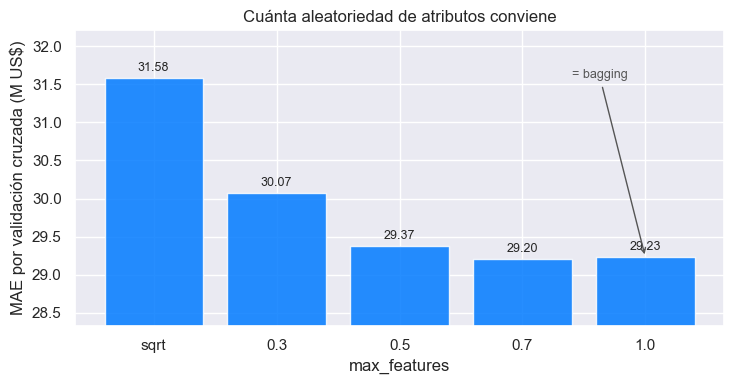

In [34]:
fig, ax = plt.subplots(figsize=(7.5, 4))
barras = ax.bar(tabla_mf.index, tabla_mf["MAE CV [M US$]"], color=AZUL, alpha=0.85)
ax.bar_label(barras, fmt="%.2f", padding=3, fontsize=9)
ax.set_ylim(tabla_mf["MAE CV [M US$]"].min() * 0.97,
            tabla_mf["MAE CV [M US$]"].max() * 1.02)
ax.set_ylabel("MAE por validación cruzada (M US$)")
ax.set_xlabel("max_features")
ax.set_title("Cuánta aleatoriedad de atributos conviene")
ax.annotate("= bagging", xy=(4, tabla_mf["MAE CV [M US$]"].iloc[-1]),
            xytext=(3.4, tabla_mf["MAE CV [M US$]"].max()),
            fontsize=9, color=GRIS,
            arrowprops={"arrowstyle": "->", "color": GRIS})
plt.tight_layout()
plt.show()

#### XGBoost — Optuna

XGBoost tiene demasiados hiperparámetros para una grilla: con ocho variables, incluso probando tres
valores de cada una harían falta $3^8 = 6561$ combinaciones. Por eso la clase 5 lo ajusta con
**Optuna**, que en lugar de recorrer una grilla fija usa un muestreador **TPE**
(*Tree-structured Parzen Estimator*): propone configuraciones, mira qué tan bien salieron y concentra
los intentos siguientes en las zonas prometedoras del espacio.

La ventaja sobre la grilla no es solo la cantidad de combinaciones, sino que los rangos son
**continuos** —`learning_rate` puede tomar cualquier valor entre 0,005 y 0,3, no tres valores
elegidos de antemano— y que los que abarcan varios órdenes de magnitud se muestrean en escala
logarítmica (`log=True`), que es como corresponde recorrerlos.

Reutilizamos la función objetivo de la clase 5 con los mismos ocho hiperparámetros y los mismos
rangos, con dos diferencias: el modelo va envuelto en nuestro pipeline con el target logarítmico, y
usamos menos intentos (`N_TRIALS`) para que el notebook corra en un tiempo razonable en Colab.

In [35]:
import optuna

N_TRIALS = 150   # la clase 5 usa 300; bajarlo o subirlo solo cambia el tiempo

optuna.logging.set_verbosity(optuna.logging.ERROR)


def objetivo(trial):
    """MAE por validación cruzada de una configuración propuesta por Optuna."""
    candidato = XGBRegressor(
        n_estimators=trial.suggest_int("n_estimators", 100, 1000, step=50),
        learning_rate=trial.suggest_float("learning_rate", 0.005, 0.3, log=True),
        max_depth=trial.suggest_int("max_depth", 2, 8),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 15),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 20, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        random_state=RANDOM_STATE, n_jobs=1,
    )
    return -cross_val_score(armar(candidato), X_train, y_train, cv=5,
                            scoring="neg_mean_absolute_error", n_jobs=-1).mean()


estudio = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
estudio.optimize(objetivo, n_trials=N_TRIALS, show_progress_bar=False)

ajustados["XGBoost"] = armar(XGBRegressor(**estudio.best_params,
                                          random_state=RANDOM_STATE, n_jobs=-1))

print(f"XGBoost          MAE CV = {estudio.best_value / 1e6:5.2f} M US$")
print(f"\nMejores hiperparámetros ({N_TRIALS} intentos):")
for clave, valor in estudio.best_params.items():
    print(f"  {clave:<18} {valor}")

XGBoost          MAE CV = 27.96 M US$

Mejores hiperparámetros (150 intentos):
  n_estimators       750
  learning_rate      0.03252422452345683
  max_depth          8
  subsample          0.5994195616663933
  colsample_bytree   0.9228727656729078
  min_child_weight   6
  reg_lambda         0.00892266883360859
  reg_alpha          2.560643424605612


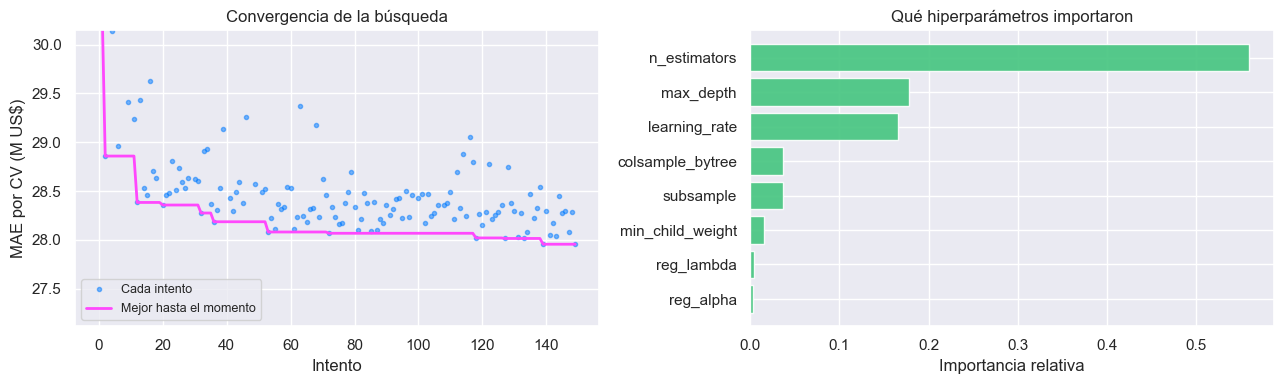

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

valores = np.array([t.value for t in estudio.trials if t.value is not None]) / 1e6
axes[0].plot(valores, "o", ms=3, alpha=0.5, color=AZUL, label="Cada intento")
axes[0].plot(np.minimum.accumulate(valores), lw=2, color=MAGENTA,
             label="Mejor hasta el momento")
axes[0].set_xlabel("Intento")
axes[0].set_ylabel("MAE por CV (M US$)")
axes[0].set_ylim(valores.min() * 0.97, np.percentile(valores, 90))
axes[0].set_title("Convergencia de la búsqueda")
axes[0].legend(fontsize=9)

importancia_hp = optuna.importance.get_param_importances(estudio)
nombres = list(importancia_hp)[::-1]
axes[1].barh(nombres, [importancia_hp[n] for n in nombres], color=VERDE, alpha=0.9)
axes[1].set_xlabel("Importancia relativa")
axes[1].set_title("Qué hiperparámetros importaron")

plt.tight_layout()
plt.show()

El gráfico de la derecha es una ventaja concreta de Optuna sobre la grilla: además de encontrar la
mejor configuración, **estima cuánto influyó cada hiperparámetro** en el resultado. Sirve para saber
dónde vale la pena afinar y qué se puede dejar en su valor por defecto.

### 9.3 Comparativa final

Ahora sí, los cuatro modelos ajustados contra el baseline, todos evaluados sobre el mismo conjunto de
testeo que no participó de ninguna búsqueda.

In [37]:
resultados_ajustados = [evaluar(f"{nombre} (ajustado)", est)
                        for nombre, est in ajustados.items()]

final = pd.DataFrame(baselines + resultados + resultados_ajustados).set_index("modelo")
final.round(3)

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Múltiplo del presupuesto,42.560,42.585,42.433,123.330,0.728,0.573,0.382
Ridge,33.252,33.602,33.509,127.556,0.627,0.496,0.339
KNN (k=15),0.000,36.057,33.707,102.788,0.642,0.503,0.571
Random Forest,14.762,29.231,28.902,85.041,0.590,0.455,0.706
XGBoost,23.133,28.670,28.291,89.520,0.592,0.453,0.674
Ridge (ajustado),33.249,33.595,33.487,127.011,0.627,0.496,0.345
KNN (k=15) (ajustado),0.000,34.729,32.566,99.522,0.634,0.507,0.598
Random Forest (ajustado),15.227,29.201,28.747,85.473,0.590,0.453,0.703
XGBoost (ajustado),18.545,27.956,27.315,83.273,0.589,0.456,0.718


In [38]:
estilo = (final
          .style
          .format({"MAE train [M US$]": "{:.1f}", "MAE CV [M US$]": "{:.1f}",
                   "MAE test [M US$]": "{:.1f}", "RMSE [M US$]": "{:.1f}",
                   "MedAPE": "{:.2f}", "MAE log10": "{:.3f}", "R2": "{:.3f}"})
          .background_gradient(subset=["MAE test [M US$]", "MAE log10"],
                               cmap="RdYlGn_r")
          .background_gradient(subset=["R2"], cmap="RdYlGn"))
estilo

,MAE train [M US$],MAE CV [M US$],MAE test [M US$],RMSE [M US$],MedAPE,MAE log10,R2
modelo,,,,,,,
Múltiplo del presupuesto,42.6,42.6,42.4,123.3,0.73,0.573,0.382
Ridge,33.3,33.6,33.5,127.6,0.63,0.496,0.339
KNN (k=15),0.0,36.1,33.7,102.8,0.64,0.503,0.571
Random Forest,14.8,29.2,28.9,85.0,0.59,0.455,0.706
XGBoost,23.1,28.7,28.3,89.5,0.59,0.453,0.674
Ridge (ajustado),33.2,33.6,33.5,127.0,0.63,0.496,0.345
KNN (k=15) (ajustado),0.0,34.7,32.6,99.5,0.63,0.507,0.598
Random Forest (ajustado),15.2,29.2,28.7,85.5,0.59,0.453,0.703
XGBoost (ajustado),18.5,28.0,27.3,83.3,0.59,0.456,0.718


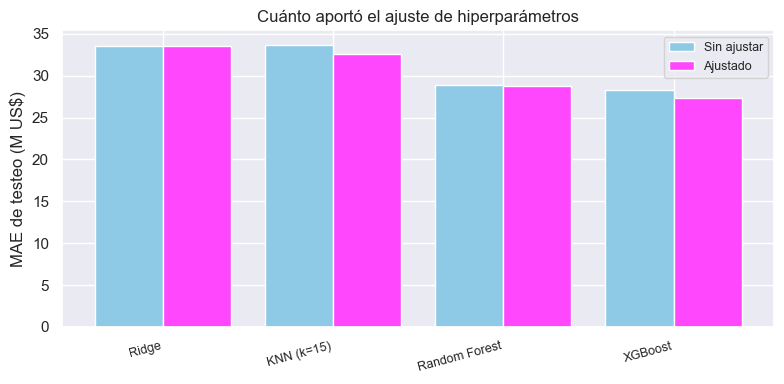

,sin ajustar,ajustado,mejora,% mejora
Ridge,33.509,33.487,0.021,0.063
KNN (k=15),33.707,32.566,1.142,3.388
Random Forest,28.902,28.747,0.155,0.536
XGBoost,28.291,27.315,0.976,3.452


In [39]:
# Cuánto le ganó a cada modelo su propio ajuste
antes = {f["modelo"]: f["MAE test [M US$]"] for f in resultados}
despues = {f["modelo"].replace(" (ajustado)", ""): f["MAE test [M US$]"]
           for f in resultados_ajustados}

efecto = pd.DataFrame({
    "sin ajustar": antes, "ajustado": despues,
}).assign(mejora=lambda d: d["sin ajustar"] - d["ajustado"],
          **{"% mejora": lambda d: (d["sin ajustar"] - d["ajustado"])
             / d["sin ajustar"] * 100})

fig, ax = plt.subplots(figsize=(8, 4))
pos = np.arange(len(efecto))
ax.bar(pos - 0.2, efecto["sin ajustar"], 0.4, label="Sin ajustar", color=CELESTE)
ax.bar(pos + 0.2, efecto["ajustado"], 0.4, label="Ajustado", color=MAGENTA)
ax.set_xticks(pos)
ax.set_xticklabels(efecto.index, rotation=15, ha="right", fontsize=9)
ax.set_ylabel("MAE de testeo (M US$)")
ax.set_title("Cuánto aportó el ajuste de hiperparámetros")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

efecto.round(3)

Dos lecturas sobre el efecto del ajuste.

**Es chico comparado con la elección del modelo.** La distancia entre familias —un lineal contra un
ensamble de árboles— es de varios millones de dólares de MAE; lo que agrega optimizar los
hiperparámetros de cada uno es un orden de magnitud menor. Dicho de otro modo: **elegir bien el
modelo importa mucho más que afinarlo**, y conviene gastar el esfuerzo en ese orden.

**Y puede ser negativo en testeo.** Las búsquedas optimizan el MAE por **validación cruzada**, que es
lo correcto, pero eso no garantiza mejorar en testeo. Si algún modelo ajustado queda apenas por
detrás del que no lo está, la lectura no es "el ajuste lo empeoró" sino que **la diferencia está
dentro del ruido**: con unas dos mil películas de testeo, unos pocos cientos de miles de dólares de
MAE no se distinguen de la variabilidad del muestreo.

Conviene tenerlo presente cada vez que se ordena una tabla de modelos: **el orden de las últimas
posiciones casi nunca es significativo**. Para afirmar que un modelo es mejor que otro hace falta que
la diferencia supere su propio error de estimación, no que aparezca más arriba en la tabla.

### 9.4 El modelo final

Nos quedamos con el mejor de la tabla y lo miramos de cerca: cómo se distribuyen sus errores y de qué
variables depende.

In [40]:
# `evaluar` dejó entrenados todos los estimadores del diccionario
nombre_mejor = final["MAE test [M US$]"].idxmin()
mejor = ajustados.get(nombre_mejor.replace(" (ajustado)", ""),
                      estimadores.get(nombre_mejor))
print(f"Mejor modelo por MAE de testeo: {nombre_mejor}")

y_pred_mejor = mejor.predict(X_test)
y_pred_base = estimadores["Múltiplo del presupuesto"].predict(X_test)

Mejor modelo por MAE de testeo: XGBoost (ajustado)


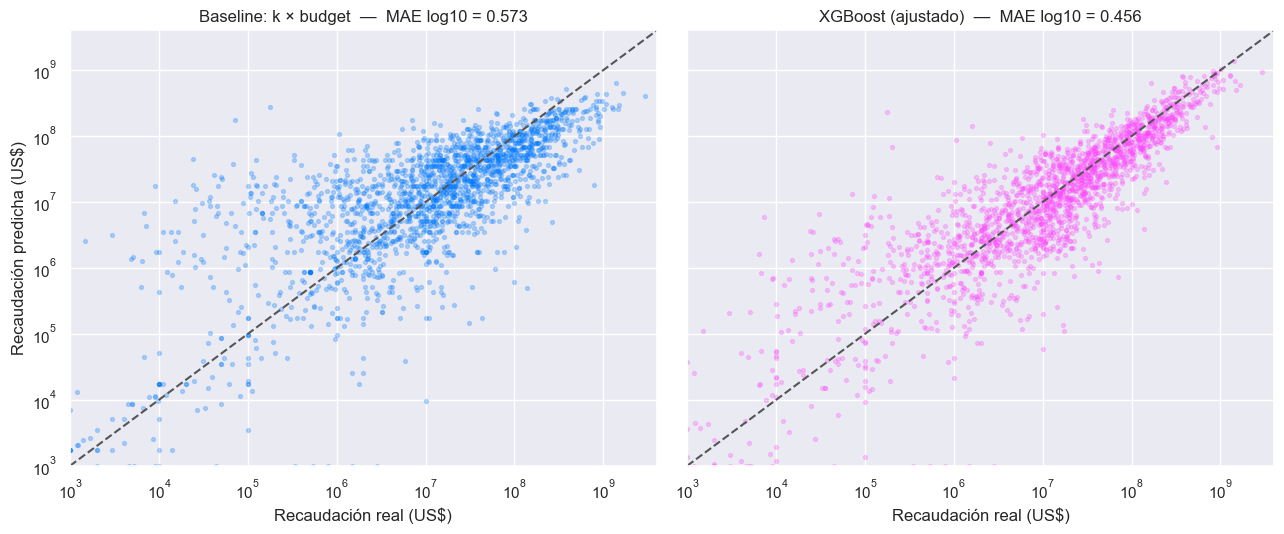

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharex=True, sharey=True)
lim = [1e3, 4e9]

for ax, pred, titulo, color in [
    (axes[0], y_pred_base, "Baseline: k × budget", AZUL),
    (axes[1], y_pred_mejor, nombre_mejor, MAGENTA),
]:
    ax.scatter(y_test, np.clip(pred, 1e3, None), s=8, alpha=0.25, color=color)
    ax.plot(lim, lim, color=GRIS, ls="--", lw=1.5)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel("Recaudación real (US$)")
    ax.set_title(f"{titulo}  —  MAE log10 = {mae_log10(y_test, pred):.3f}")

axes[0].set_ylabel("Recaudación predicha (US$)")
plt.tight_layout()
plt.show()

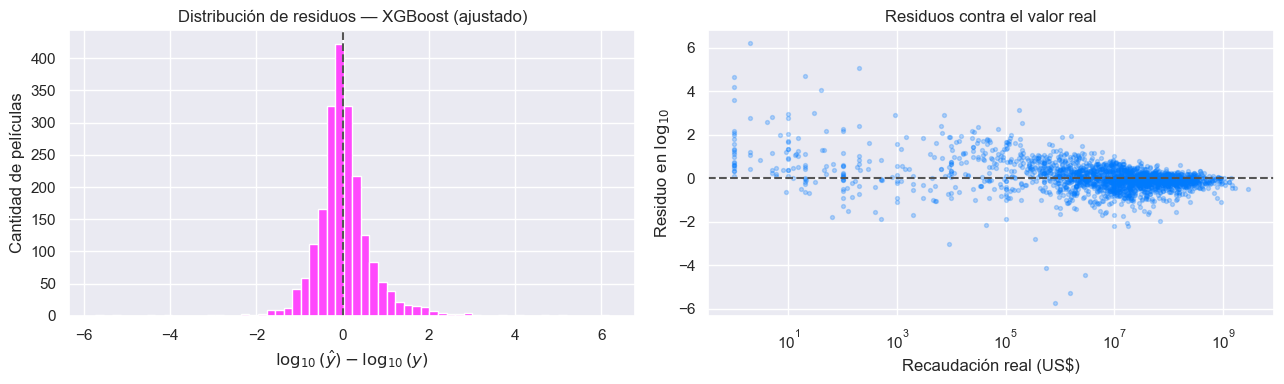

Residuo mediano: -0.025 órdenes de magnitud
Predicciones dentro de un factor 2 del valor real: 50.8%


In [42]:
residuos = np.log10(np.clip(y_pred_mejor, 1, None)) - np.log10(np.clip(y_test, 1, None))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(residuos, bins=60, color=MAGENTA, edgecolor="white")
axes[0].axvline(0, color=GRIS, ls="--", lw=1.5)
axes[0].set_xlabel("$\\log_{10}(\\hat{y}) - \\log_{10}(y)$")
axes[0].set_ylabel("Cantidad de películas")
axes[0].set_title(f"Distribución de residuos — {nombre_mejor}")

axes[1].scatter(y_test, residuos, s=8, alpha=0.25, color=AZUL)
axes[1].axhline(0, color=GRIS, ls="--", lw=1.5)
axes[1].set_xscale("log")
axes[1].set_xlabel("Recaudación real (US$)")
axes[1].set_ylabel("Residuo en $\\log_{10}$")
axes[1].set_title("Residuos contra el valor real")

plt.tight_layout()
plt.show()

print(f"Residuo mediano: {np.median(residuos):+.3f} órdenes de magnitud")
print(f"Predicciones dentro de un factor 2 del valor real: "
      f"{(np.abs(residuos) < np.log10(2)).mean():.1%}")

El gráfico de residuos contra el valor real muestra el patrón típico de un modelo entrenado en
escala logarítmica sobre datos muy dispersos: **sobreestima las películas de recaudación baja y
subestima las de recaudación muy alta**, es decir, regresa hacia la media. Es esperable y es el
precio de optimizar el error en logaritmos.

#### Importancia de las variables

Usamos `permutation_importance` sobre el conjunto de testeo: mide cuánto empeora el MAE al permutar
al azar cada columna. A diferencia de la importancia interna de los árboles, no está sesgada hacia
las variables de alta cardinalidad y se calcula sobre datos que el modelo no vio.

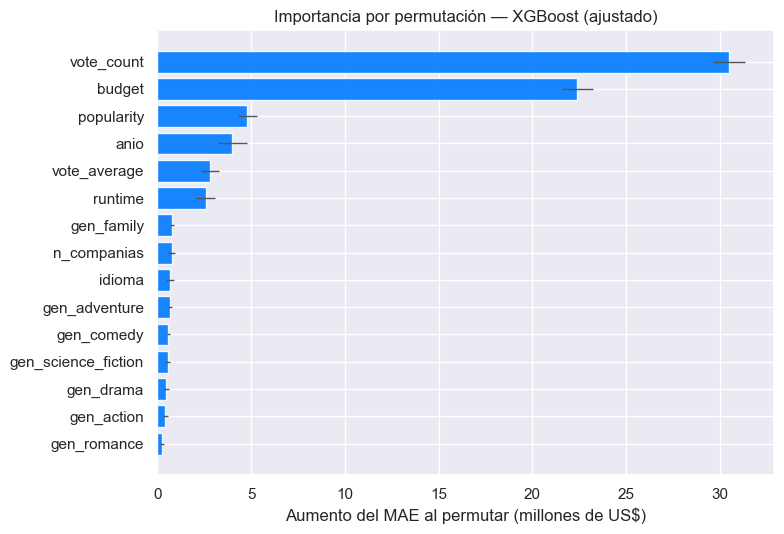

In [43]:
from sklearn.inspection import permutation_importance

importancias = permutation_importance(
    mejor, X_test, y_test, n_repeats=10,
    scoring="neg_mean_absolute_error",
    random_state=RANDOM_STATE, n_jobs=-1,
)

medias = pd.Series(importancias.importances_mean, index=X_test.columns)
desvios = pd.Series(importancias.importances_std, index=X_test.columns)

ranking = medias.sort_values(ascending=False).head(15) / 1e6
errores = desvios[ranking.index] / 1e6

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(ranking.index[::-1], ranking.values[::-1], xerr=errores.values[::-1],
        color=AZUL, alpha=0.9, error_kw={"ecolor": GRIS, "lw": 1})
ax.set_xlabel("Aumento del MAE al permutar (millones de US$)")
ax.set_title(f"Importancia por permutación — {nombre_mejor}")
plt.tight_layout()
plt.show()

---
## 10. Conclusiones

**Sobre los datos.** El dataset original tiene cerca de un millón de películas, pero apenas una
fracción mínima trae presupuesto y recaudación cargados. El trabajo real del EDA no fue encontrar
correlaciones sino **descubrir que el 0 es un `NaN` disfrazado** y aceptar el costo de quedarnos con
un dataset dos órdenes de magnitud más chico. Un modelo entrenado sobre el crudo habría aprendido,
sobre todo, a predecir cero.

**Sobre el target.** La recaudación abarca nueve órdenes de magnitud. Modelar directamente en
dólares hace que la función de pérdida quede dominada por un puñado de *blockbusters*; pasar a
escala logarítmica es lo que vuelve tratable el problema. Reportar el MAE en dólares **y** en
$\log_{10}$ evita sacar conclusiones equivocadas a partir de una sola métrica.

**Sobre las métricas.** El resultado metodológicamente más valioso del trabajo es que **las métricas
se contradicen**, y que esa contradicción es informativa. La regresión lineal sobre logaritmos gana
en MAE $\log_{10}$ y se derrumba en $R^2$; el mismo modelo es "el mejor" o "peor que predecir la
mediana" según qué columna se mire. Con un target así de disperso, elegir una única métrica
equivale a elegir de antemano el ganador, y por eso reportamos varias en paralelo.

**Sobre los modelos.** La brecha grande está entre *no usar información* y *usar el presupuesto*;
la brecha entre un modelo lineal en logaritmos y uno de árboles es real pero mucho más chica. Eso
dice algo del fenómeno: la relación presupuesto → recaudación es aproximadamente una **ley de
potencias**, y lo que agregan los modelos no lineales es corregirla según género, idioma, época y
recepción del público.

**Sobre las *features*.** El conjunto quedó deliberadamente chico: presupuesto, popularidad, votos,
duración, año, idioma, cantidad de productoras y los doce géneros principales. Varias variables que
parecían prometedoras —la presencia de sitio web o de *tagline*, la cantidad de géneros o de idiomas
hablados— no entraron, porque **`budget` ya carga esa información**: casi todas eran distintas formas
de medir el tamaño de la producción. Agregar variables plausibles no es gratis, sobre todo para
modelos basados en distancias como KNN, donde cada columna sin señal degrada la noción de "película
parecida".

**Limitaciones y caminos siguientes:**

- **Sesgo de selección.** El modelo vale para películas con distribución comercial, no para el
  catálogo completo de TMDB. Cualquier extrapolación fuera de ese universo es injustificada.
- **Variables posteriores al estreno.** `popularity`, `vote_count` y `vote_average` no están
  disponibles antes del estreno. Un experimento valioso es reentrenar **sin ellas** para medir el
  desempeño en el escenario de decisión real (¿financiar o no?), que es bastante más difícil.
- **Validación temporal.** Partimos train/test al azar. Para un uso realista corresponde un corte
  cronológico —entrenar con estrenos anteriores a cierto año y testear con los posteriores— que
  además evita filtrar información del futuro.
- **Inflación.** Los montos son nominales: 100 millones de 1990 no son 100 millones de 2023.
  Deflactar por IPC debería mejorar la comparabilidad entre épocas.
- **Features sin explotar.** `keywords`, `overview` y las productoras admiten representaciones más
  ricas (TF-IDF, *target encoding* de los estudios grandes) que quedaron fuera de este trabajo.